[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Daniel-534/Astroestadistica/blob/main/Clases/Clase20260514.ipynb)

Método de transformación inversa.
Pg 287 (311)

**Problema:** Genere $n = 1000$ deviates exponenciales con parámetro de escala $\lambda = 3$ usando el método de transformación inversa descrito en la Sección 7.2 de *Numerical Recipes in C* [[1]], ecuación (7.2.5):

$$
x = -\lambda \cdot \ln(r), \quad r \sim \mathcal{U}(0,1]
$$

Grafique el histograma de las muestras generadas (con `density=True`) y superponga la curva teórica de la función de densidad de probabilidad:

$$
p(x) = \frac{1}{\lambda} e^{-x/\lambda}, \quad x \geq 0
$$

---

## Otras preguntas mínimas en el mismo contexto (Sección 7.2)

1. **Validación estadística básica:** Calcule la media y varianza muestral de los deviates generados y compárelas con los valores teóricos $\mathbb{E}[X] = \lambda$ y $\mathrm{Var}(X) = \lambda^2$.

2. **Función de distribución acumulada empírica:** Grafique la ECDF de las muestras exponenciales junto con la CDF teórica $F(x) = 1 - e^{-x/\lambda}$.

3. **Generación de deviates normales (Box-Muller):** Implemente el método de Box-Muller (ecuación 7.2.10 del libro) para generar pares de deviates normales estándar a partir de uniformes, y grafique un histograma de los resultados superpuesto con $\phi(y) = \frac{1}{\sqrt{2\pi}}e^{-y^2/2}$.

4. **Efecto del tamaño de muestra:** Repita la generación con $n = 100, 500, 2000$ y grafique en una misma figura los tres histogramas para visualizar la convergencia hacia la PDF teórica.

5. **Comparación de semillas:** Genere dos conjuntos de muestras con semillas diferentes y calcule la correlación entre sus medias muestrales para verificar independencia.

---

**Referencia:**  
[[1]] Press, W. H., et al. (1992). *Numerical Recipes in C*, 2nd ed. Cambridge University Press. Sección 7.2: "Transformation Method: Exponential and Normal Deviates", pp. 287-291.

In [4]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
l, n = 3, 1000
np.random.seed(np.random.randint(0,1000)) # Semilla aleatoria
r = np.random.uniform(0,1,n)

expdev = lambda l, r: -l * np.log(r)
samples = expdev(l, r)

x = np.linspace(0, samples.max(), 200)
pdf = (1/l) * np.exp(-x/l)

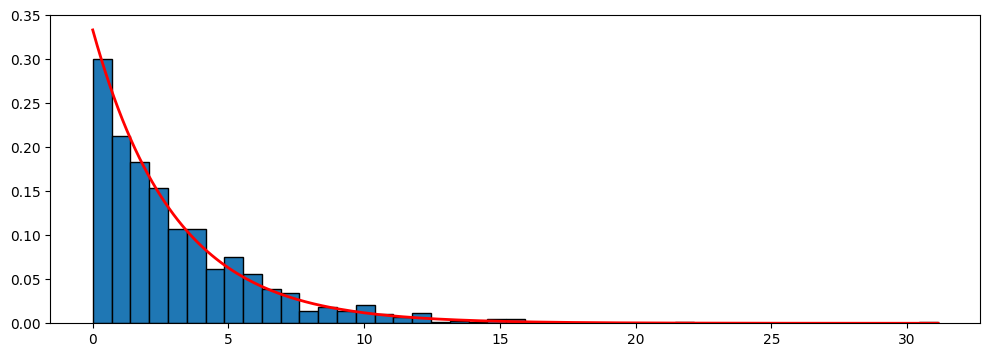

In [6]:
plt.figure(figsize=(6*2,4))
plt.hist(samples, bins='auto', density=True, edgecolor="k")
plt.plot(x, pdf, 'r-', linewidth=2);

1. **Validación estadística básica:** Calcule la media y varianza muestral de los deviates generados y compárelas con los valores teóricos $\mathbb{E}[X] = \lambda$ y $\mathrm{Var}(X) = \lambda^2$.

In [7]:
print(f"Media: {np.mean(samples):.4f} (teórica: {l})")
print(f"Varianza: {np.var(samples):.4f} (teórica: {l**2})")

Media: 3.0991 (teórica: 3)
Varianza: 9.4469 (teórica: 9)
